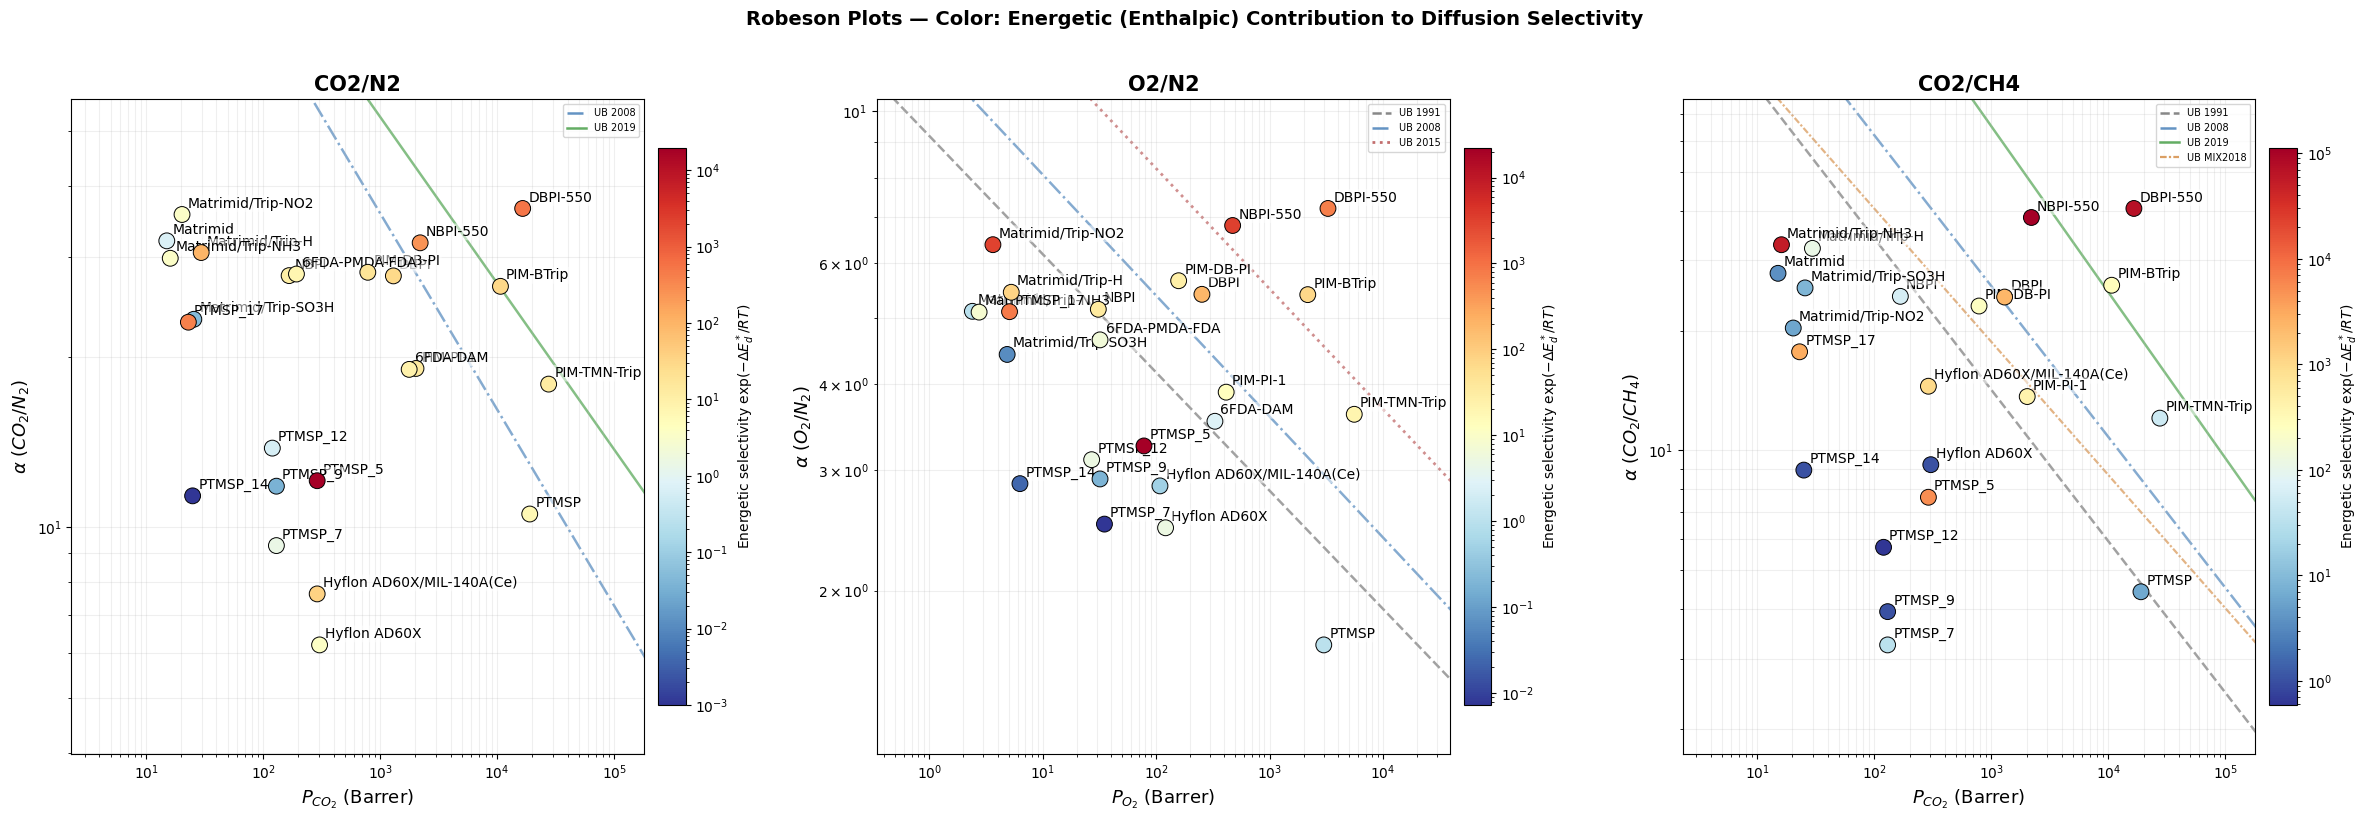

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

df = pd.read_csv("../data/data.csv")

upperbounds_dict = {
    "CO2_CH4": {"1991": [1073700, -2.63], "2008": [5369140, -2.64],
                "2019": [22584455, -2.40], "MIX2018": [6398467, -2.99]},
    "CO2_N2":  {"2008": [30967000, -2.89], "2019": [755584213, -3.41]},
    "O2_N2":   {"1991": [389224, -5.80], "2008": [1396000, -5.67], "2015": [16700000, -5.7]},
}

gas_pair_to_ub_key = {"O2/N2": "O2_N2", "CO2/N2": "CO2_N2", "CO2/CH4": "CO2_CH4"}

ub_line_styles = {
    "1991":    {"ls": "--",               "lw": 1.8, "color": "#555555"},
    "2008":    {"ls": "-.",               "lw": 1.8, "color": "#2266AA"},
    "2015":    {"ls": ":",                "lw": 2.0, "color": "#AA3333"},
    "2019":    {"ls": "-",                "lw": 1.8, "color": "#228B22"},
    "MIX2018": {"ls": (0, (3, 1, 1, 1)), "lw": 1.6, "color": "#CC7722"},
}

plot_configs = [
    {
        "gas_pair": "CO2/N2",
        "x_col": "P(CO2)",
        "sel_col": "P(CO2)/P(N2)",
        "ener_col": "Ent_P(CO2)/P(N2)",
        "xlabel": r"$P_{CO_2}$ (Barrer)",
        "ylabel": r"$\alpha$ ($CO_2/N_2$)",
    },
    {
        "gas_pair": "O2/N2",
        "x_col": "P(O2)",
        "sel_col": "P(O2)/P(N2)",
        "ener_col": "Ent_P(O2)/P(N2)",
        "xlabel": r"$P_{O_2}$ (Barrer)",
        "ylabel": r"$\alpha$ ($O_2/N_2$)",
    },
    {
        "gas_pair": "CO2/CH4",
        "x_col": "P(CO2)",
        "sel_col": "P(CO2)/P(CH4)",
        "ener_col": "Ent_P(CO2)/P(CH4)",
        "xlabel": r"$P_{CO_2}$ (Barrer)",
        "ylabel": r"$\alpha$ ($CO_2/CH_4$)",
    },
]

PAD = 0.25

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for cfg, ax in zip(plot_configs, axes):
    gas_pair = cfg["gas_pair"]

    sub = df.dropna(subset=[cfg["x_col"], cfg["sel_col"], cfg["ener_col"]])
    x = sub[cfg["x_col"]].values
    y = sub[cfg["sel_col"]].values
    c = sub[cfg["ener_col"]].values
    names = sub["Polymer"].values

    log_x_min, log_x_max = np.log10(x.min()), np.log10(x.max())
    log_y_min, log_y_max = np.log10(y.min()), np.log10(y.max())
    x_span = log_x_max - log_x_min
    y_span = log_y_max - log_y_min
    xlim = (10 ** (log_x_min - PAD * x_span), 10 ** (log_x_max + PAD * x_span))
    ylim = (10 ** (log_y_min - PAD * y_span), 10 ** (log_y_max + PAD * y_span))

    norm = mcolors.LogNorm(vmin=max(c.min(), 1e-3), vmax=c.max())
    sc = ax.scatter(
        x, y, c=c, cmap="RdYlBu_r", norm=norm,
        s=130, edgecolors="black", linewidths=0.7, zorder=5,
    )

    ub_key = gas_pair_to_ub_key.get(gas_pair)
    ub_handles = []
    if ub_key and ub_key in upperbounds_dict:
        y_range = np.logspace(np.log10(ylim[0]), np.log10(ylim[1]), 500)
        for year, (k, n) in sorted(upperbounds_dict[ub_key].items()):
            x_ub = k * y_range ** n
            sty = ub_line_styles.get(year, {"ls": "--", "lw": 1.5, "color": "gray"})
            ax.plot(x_ub, y_range, **sty, alpha=0.55, zorder=1)
            ub_handles.append(Line2D([0], [0], **sty, alpha=0.7, label=f"UB {year}"))

    for i, nm in enumerate(names):
        ax.annotate(
            nm, (x[i], y[i]), fontsize=10, xytext=(4, 5),
            textcoords="offset points", ha="left",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.5, ec="none"),
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(cfg["xlabel"], fontsize=13)
    ax.set_ylabel(cfg["ylabel"], fontsize=13)
    ax.set_title(gas_pair, fontsize=15, fontweight="bold")
    ax.grid(True, alpha=0.2, which="both")

    if ub_handles:
        ax.legend(handles=ub_handles, fontsize=7, loc="upper right")

    cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(r"Energetic selectivity $\exp(-\Delta E_d^*/RT)$", fontsize=10)

plt.suptitle(
    "Robeson Plots — Color: Energetic (Enthalpic) Contribution to Diffusion Selectivity",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

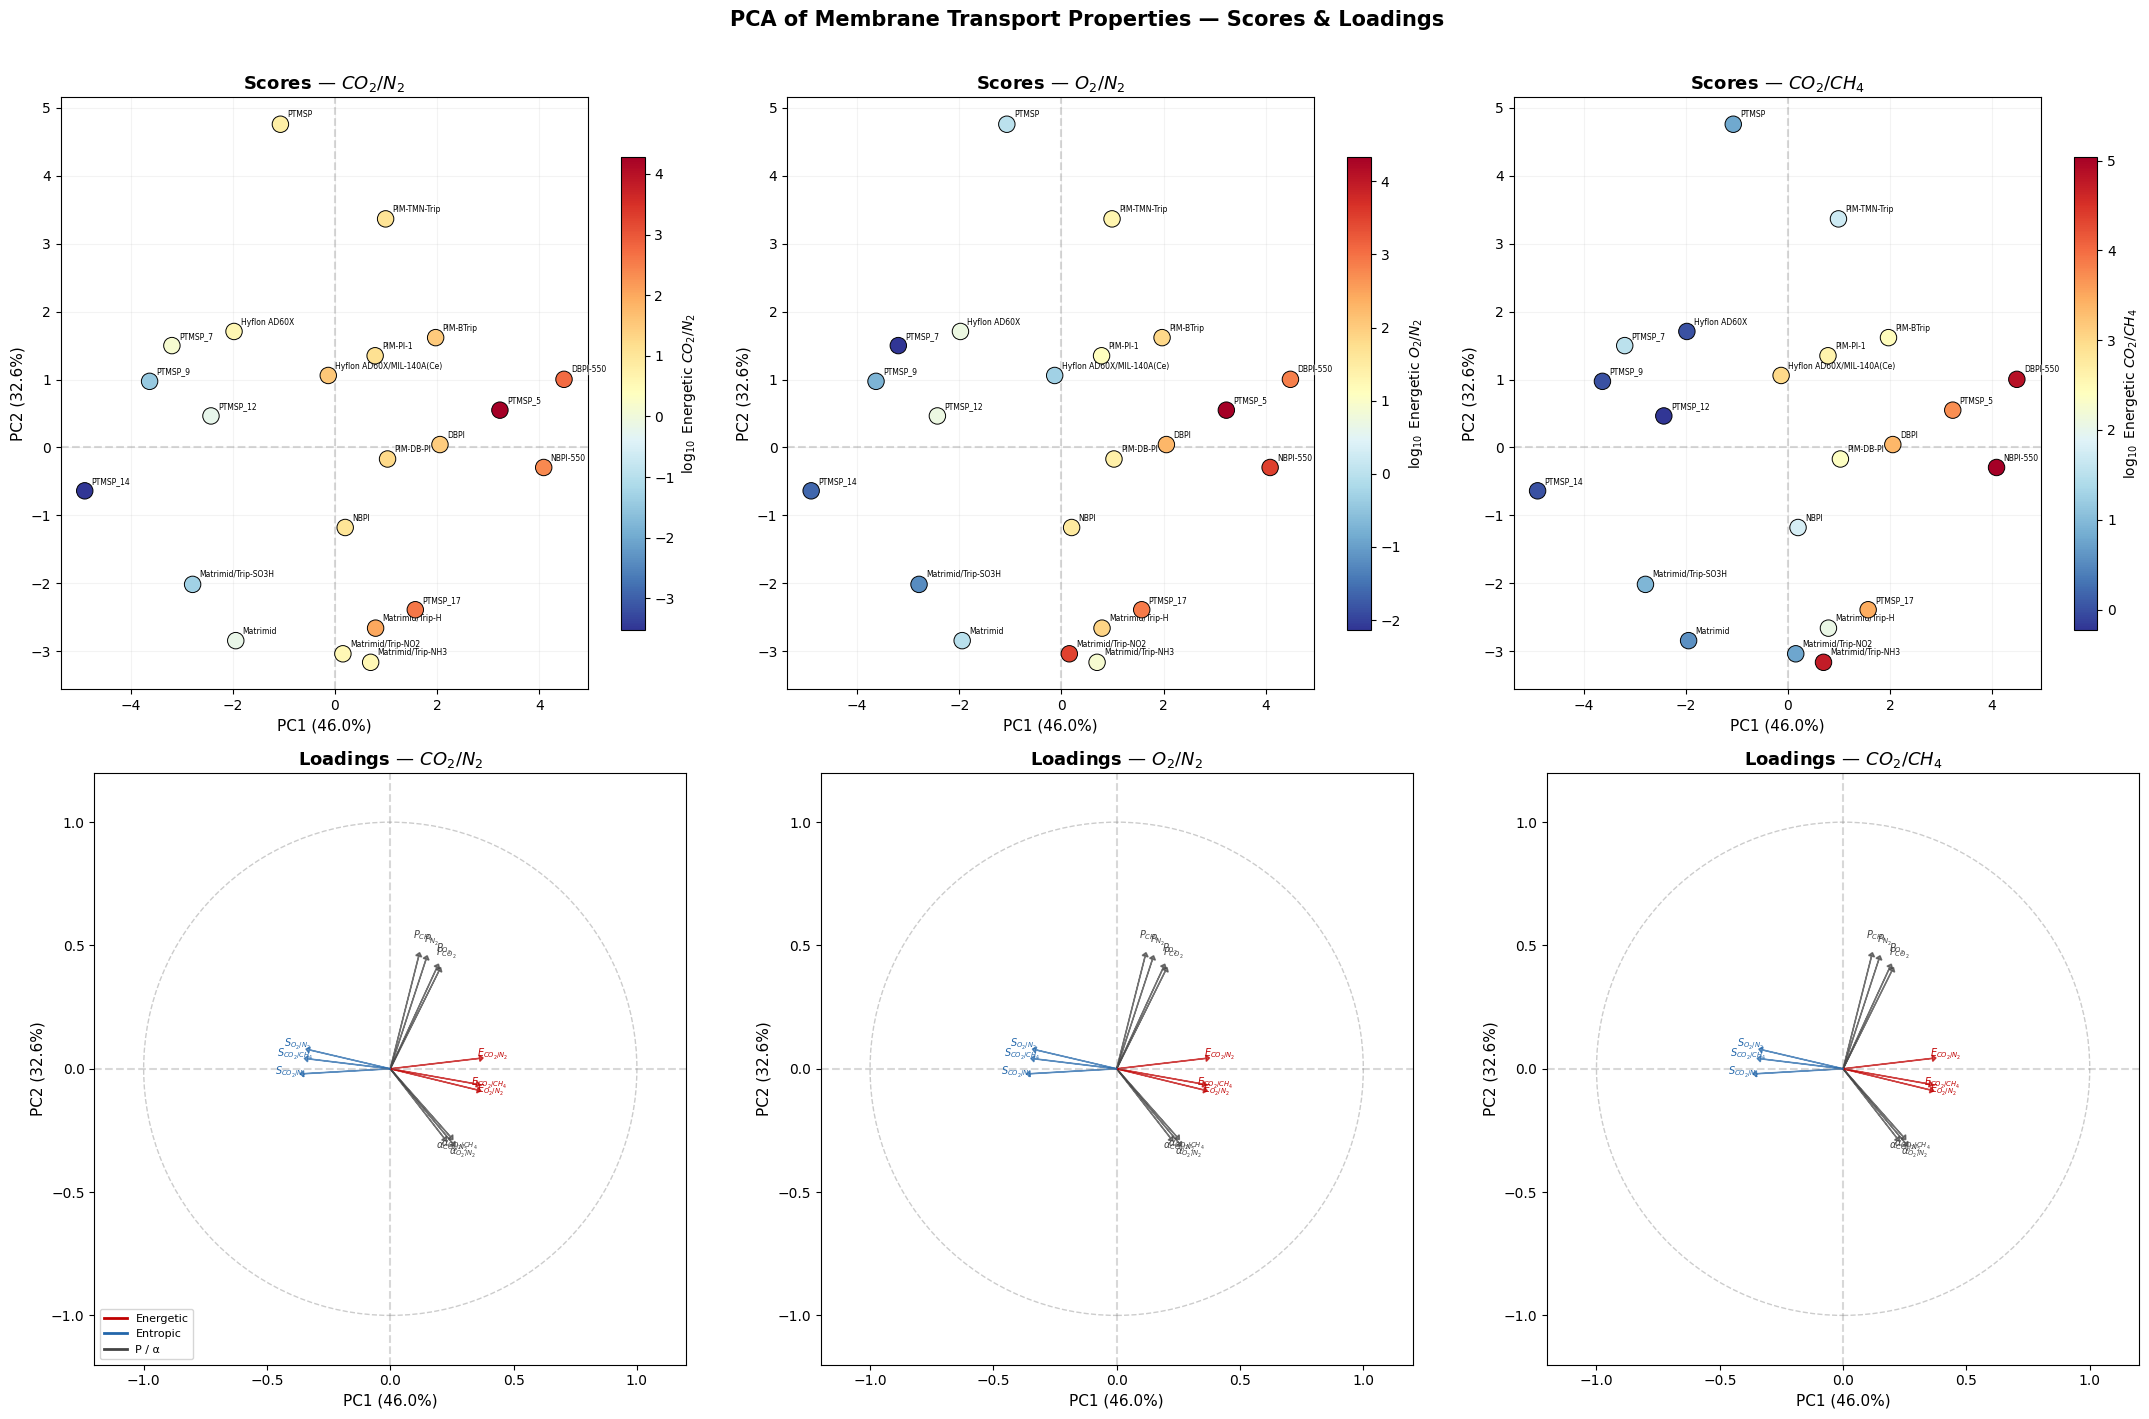

In [5]:
feature_cols = [
    "P(CO2)", "P(CH4)", "P(O2)", "P(N2)",
    "P(CO2)/P(N2)", "P(O2)/P(N2)", "P(CO2)/P(CH4)",
    "Ent_P(CO2)/P(N2)", "Ent_P(O2)/P(N2)", "Ent_P(CO2)/P(CH4)",
    "Entr_P(CO2)/P(N2)", "Entr_P(O2)/P(N2)", "Entr_P(CO2)/P(CH4)",
]

feature_labels = [
    r"$P_{CO_2}$", r"$P_{CH_4}$", r"$P_{O_2}$", r"$P_{N_2}$",
    r"$\alpha_{CO_2/N_2}$", r"$\alpha_{O_2/N_2}$", r"$\alpha_{CO_2/CH_4}$",
    r"$E_{CO_2/N_2}$", r"$E_{O_2/N_2}$", r"$E_{CO_2/CH_4}$",
    r"$S_{CO_2/N_2}$", r"$S_{O_2/N_2}$", r"$S_{CO_2/CH_4}$",
]

df_clean = df.dropna(subset=feature_cols).copy()
df_clean = df_clean[df_clean[feature_cols].gt(0).all(axis=1)]

df_log = df_clean[feature_cols].apply(np.log10)
df_log.index = df_clean["Polymer"].values

X_scaled = StandardScaler().fit_transform(df_log)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
loadings = pca.components_[:2].T

color_configs = [
    {"col": "Ent_P(CO2)/P(N2)",  "title": r"$CO_2/N_2$",
     "cbar": r"$\log_{10}$ Energetic $CO_2/N_2$"},
    {"col": "Ent_P(O2)/P(N2)",   "title": r"$O_2/N_2$",
     "cbar": r"$\log_{10}$ Energetic $O_2/N_2$"},
    {"col": "Ent_P(CO2)/P(CH4)", "title": r"$CO_2/CH_4$",
     "cbar": r"$\log_{10}$ Energetic $CO_2/CH_4$"},
]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

for j, ccfg in enumerate(color_configs):
    c = df_log.loc[df_log.index, ccfg["col"]].values
    norm = plt.Normalize(vmin=c.min(), vmax=c.max())

    ax = axes[0, j]
    sc = ax.scatter(
        X_pca[:, 0], X_pca[:, 1], c=c, cmap="RdYlBu_r", norm=norm,
        s=140, edgecolors="black", linewidths=0.7, zorder=5,
    )
    for i, name in enumerate(df_log.index):
        ax.annotate(
            name, (X_pca[i, 0], X_pca[i, 1]), fontsize=5.5, xytext=(5, 5),
            textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.5, ec="none"),
        )
    ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=11)
    ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=11)
    ax.set_title(f"Scores — {ccfg['title']}", fontsize=13, fontweight="bold")
    ax.axhline(0, ls="--", color="gray", alpha=0.3)
    ax.axvline(0, ls="--", color="gray", alpha=0.3)
    ax.grid(True, alpha=0.15)
    fig.colorbar(sc, ax=ax, shrink=0.8, label=ccfg["cbar"])

    ax = axes[1, j]
    for i, label in enumerate(feature_labels):
        color = "#C00000" if "E_{" in label else "#2266AA" if "S_{" in label else "#444444"
        ax.arrow(
            0, 0, loadings[i, 0], loadings[i, 1],
            head_width=0.025, head_length=0.015, fc=color, ec=color, alpha=0.7,
        )
        ax.text(
            loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, label,
            fontsize=7, ha="center", color=color,
        )
    circle = plt.Circle((0, 0), 1, fill=False, ls="--", color="gray", alpha=0.4)
    ax.add_patch(circle)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=11)
    ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=11)
    ax.set_title(f"Loadings — {ccfg['title']}", fontsize=13, fontweight="bold")
    ax.axhline(0, ls="--", color="gray", alpha=0.3)
    ax.axvline(0, ls="--", color="gray", alpha=0.3)
    ax.set_aspect("equal")

    if j == 0:
        legend_elements = [
            Line2D([0], [0], color="#C00000", lw=2, label="Energetic"),
            Line2D([0], [0], color="#2266AA", lw=2, label="Entropic"),
            Line2D([0], [0], color="#444444", lw=2, label="P / α"),
        ]
        ax.legend(handles=legend_elements, fontsize=8, loc="lower left")

plt.suptitle(
    "PCA of Membrane Transport Properties — Scores & Loadings",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()